# Compare parameter estimation via stepwise BFGS with evofr

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import evofr as ef

from viral_variant_comp.simulate_count_data import create_count_data
from viral_variant_comp.plotting import plot_viral_composition_dual, plot_heatmap, plot_confidence_intervals_deviation
from viral_variant_comp.estimate import calculate_cooccurence
from viral_variant_comp.evaluate import evaluate_result
from viral_variant_comp.estimate import BFGSCompositionEstimator, StepwiseBFGSCompositionEstimator, EvofrCompositionEstimator


/opt/homebrew/Caskroom/miniforge/base/envs/neherlab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


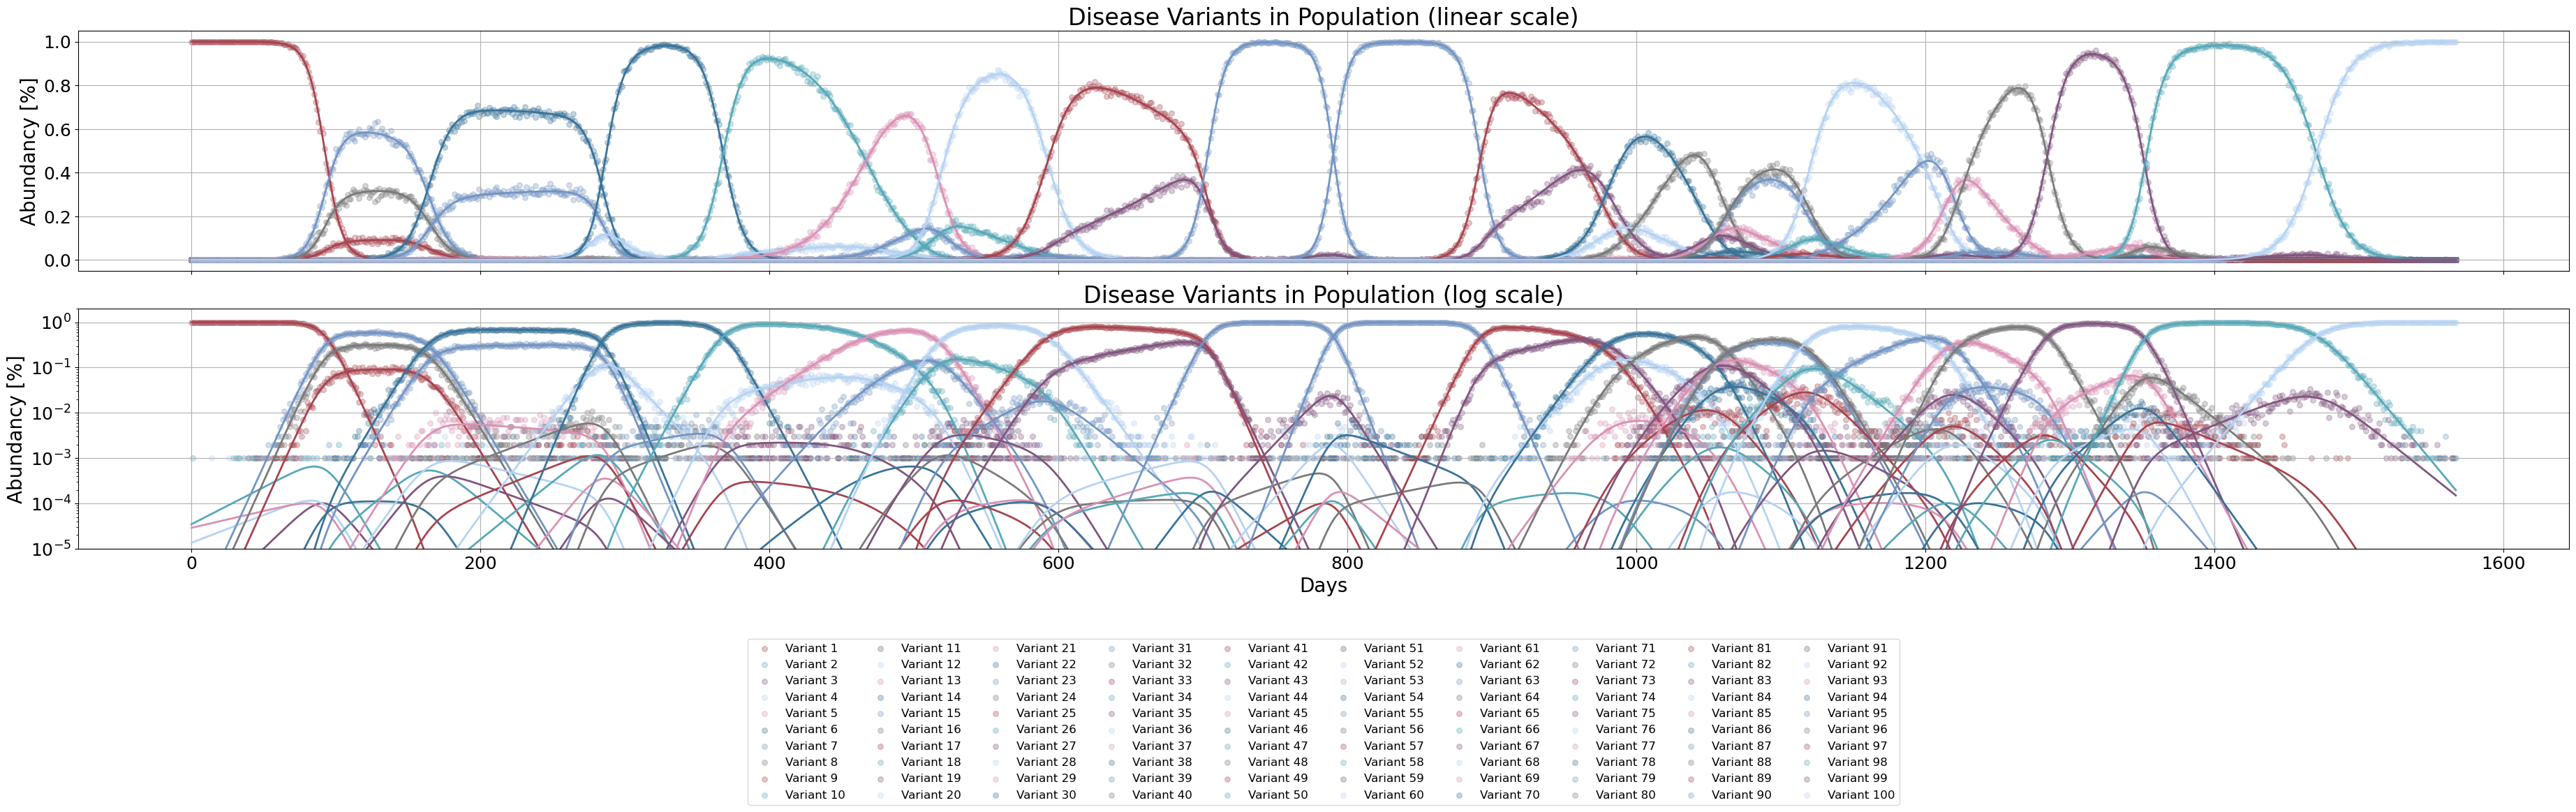

In [2]:
n_variants = 100
n_samples = 1000

delta_gr_range = 0.2
s_0 = 0.
o_0 = 0.
rate = 1/14  # per day, on average one new variant every two weeks
freq_entering_variants = 0.0001

data = create_count_data(n_variants = n_variants, delta_gr_range = delta_gr_range, new_var_rate = rate, freq_entering_variants = freq_entering_variants, n_samples = n_samples, s_0 = s_0, o_0 = o_0, reorder=True, seed=5)
plot_viral_composition_dual(data['counts'], data['freq'], y_range = (1e-5, 2), path_to_save="figures/count_data_100var.png")

## Use Evofr to estimate variant parameters
Evofr offers two main methods to estimate growth rate and log initial frequency from variant count data:
- MCMC sampling to approximate full posterior
    - implemented with inference method InferNUTS
- SVI (stochastic variational inference) to approximate MAP estimate
    - faster than MCMC
    - implemented with inference method InferMAP

In [4]:
estimator_evofr = EvofrCompositionEstimator(data['counts'], iterations=1000000)
estimator_evofr.fit()
result_evofr = estimator_evofr.get_results()

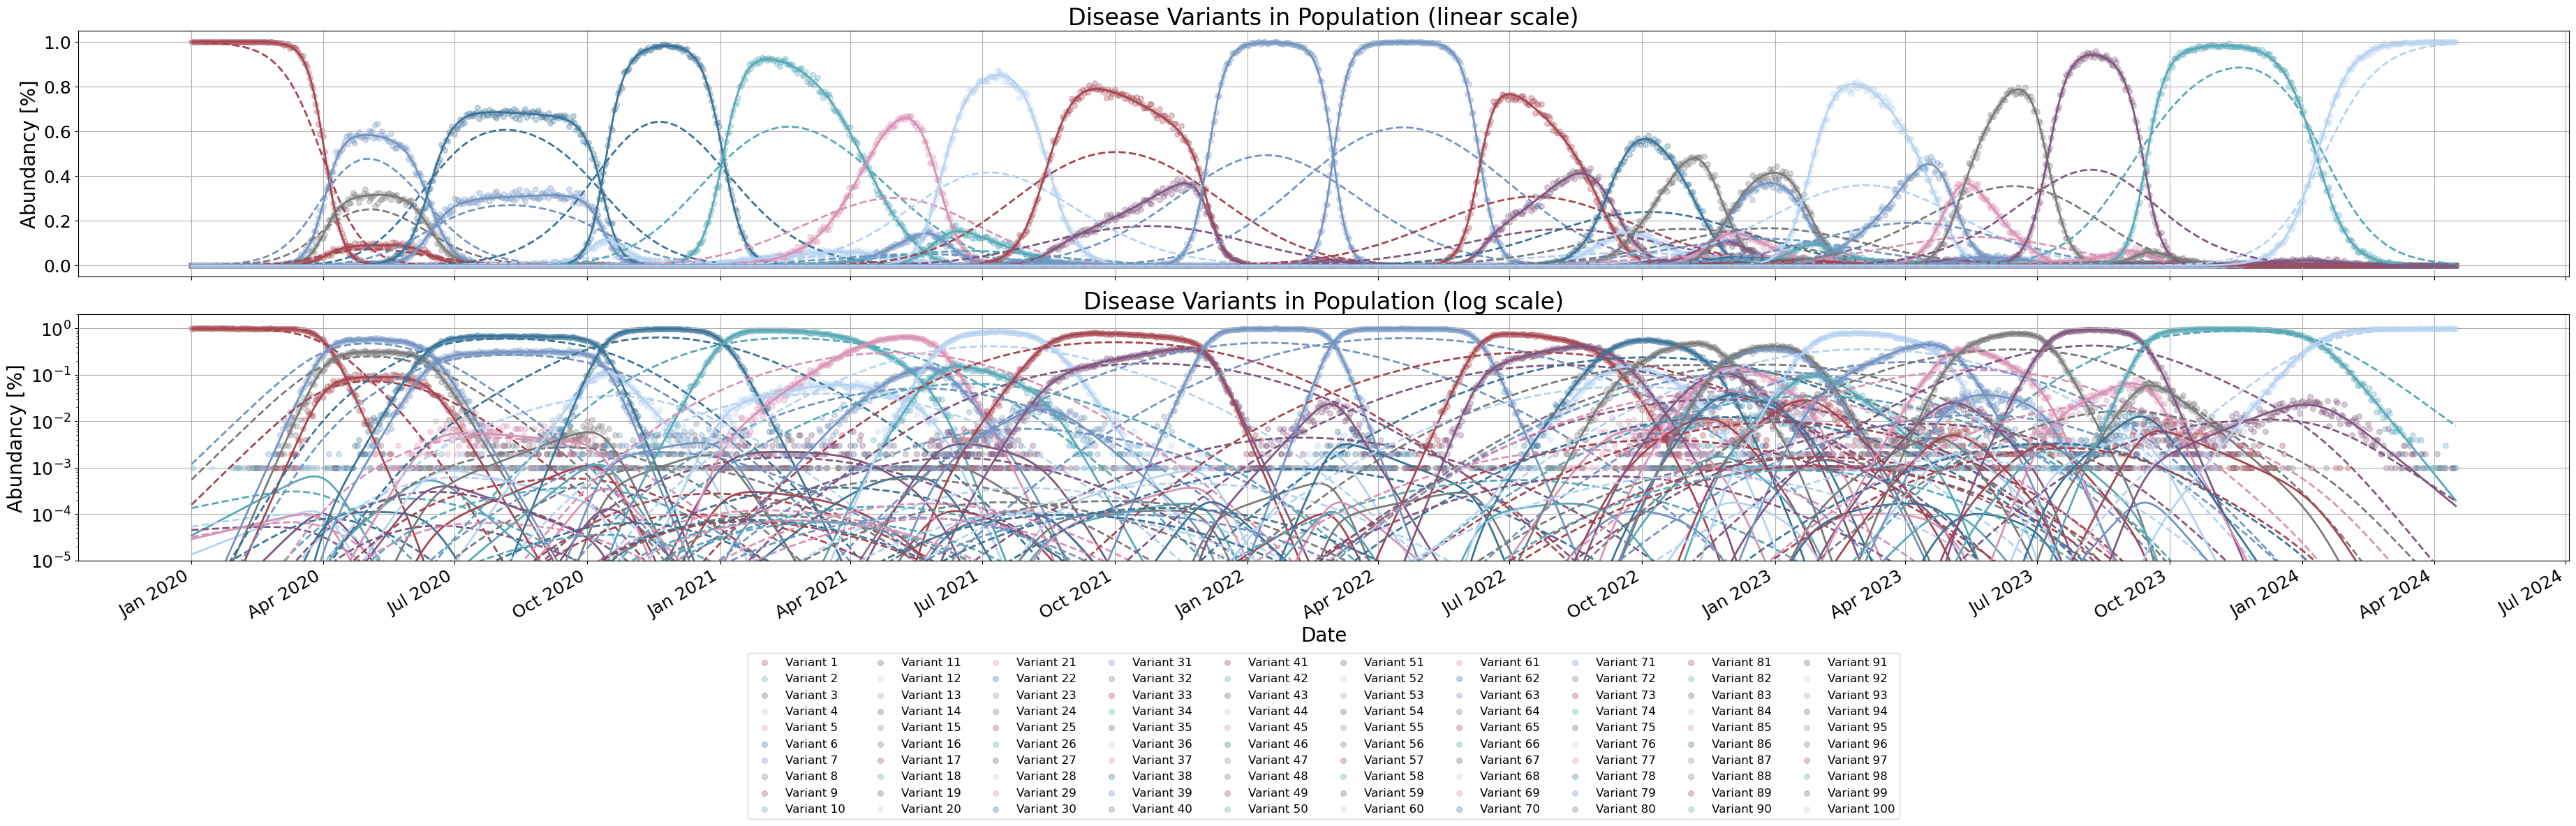

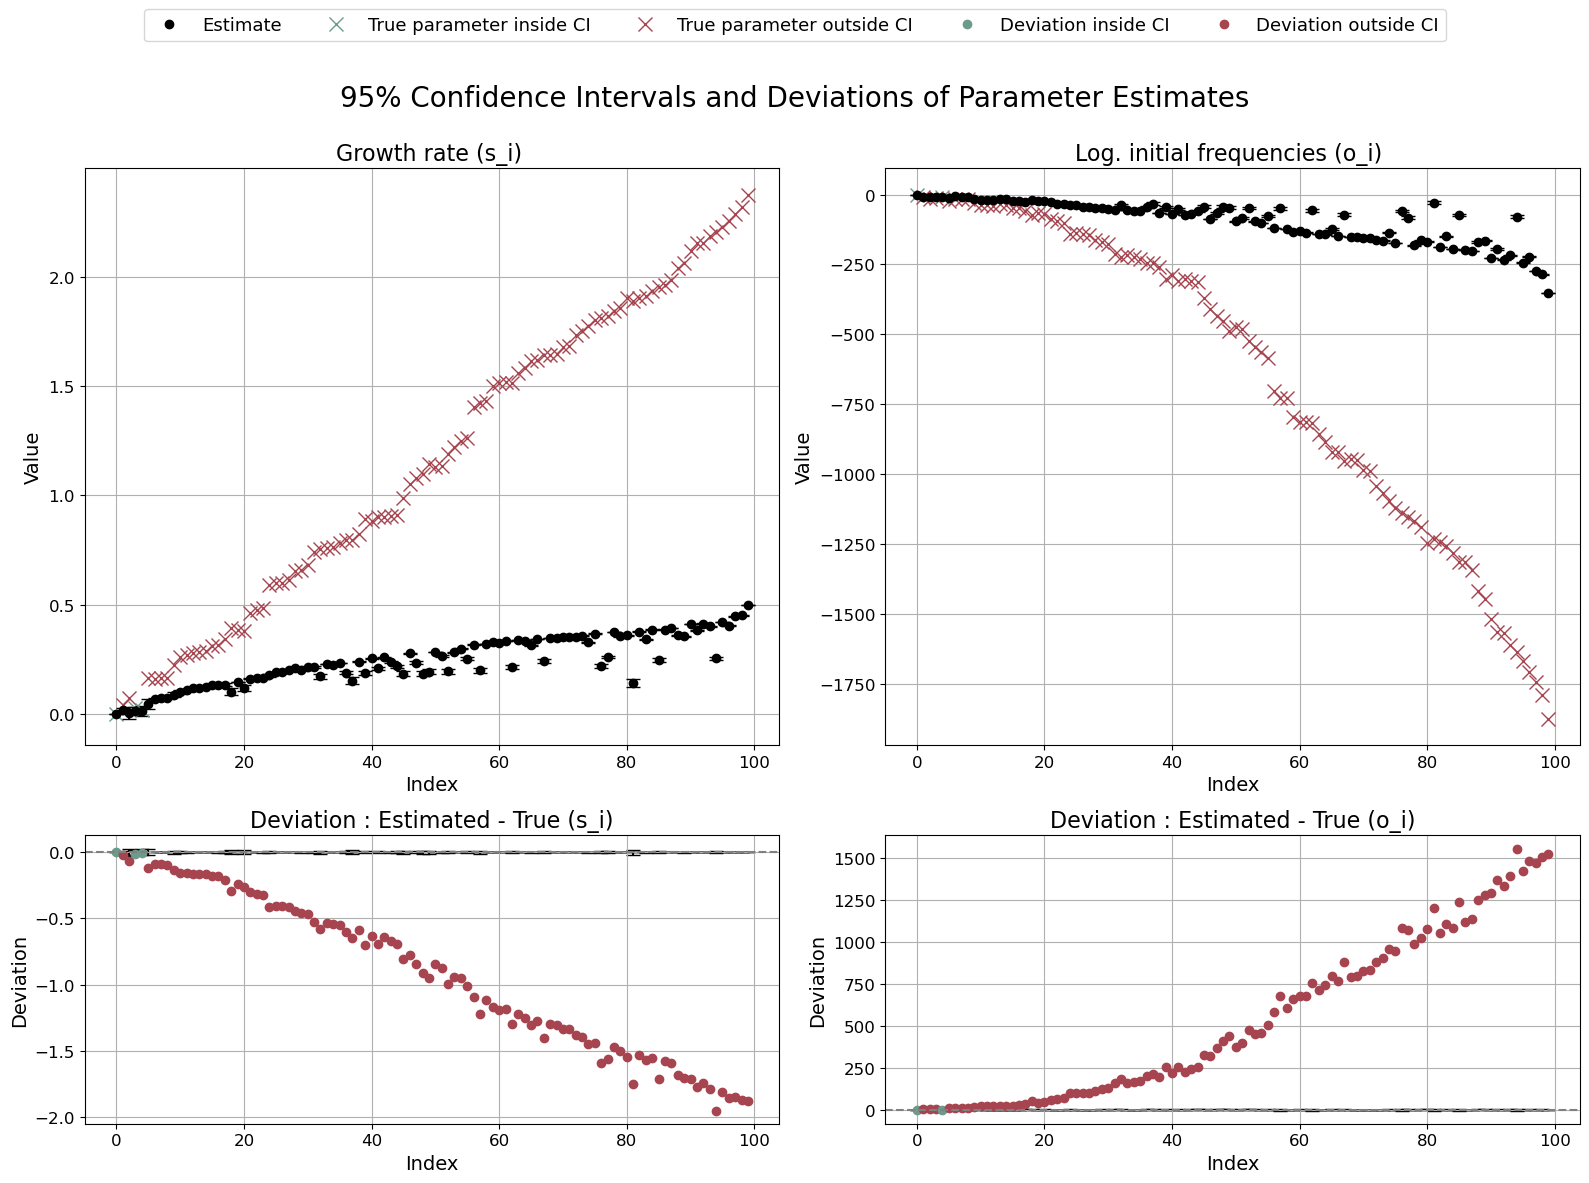

In [15]:
plot_viral_composition_dual(data['counts'], data['freq'], result_evofr['composition_estimate'], y_range = (1e-5, 2), start_date="2020-01-01", path_to_save="figures/evofr_estimated_composition_100_1000000iter.png")

df = evaluate_result(result_evofr['growth_rate_estimate'], result_evofr['log_init_freq_estimate'], result_evofr['hess_inv'], data['growth_rates'], data['log_init_freq'])
plot_confidence_intervals_deviation(df)

## Compare to BFGS optimization

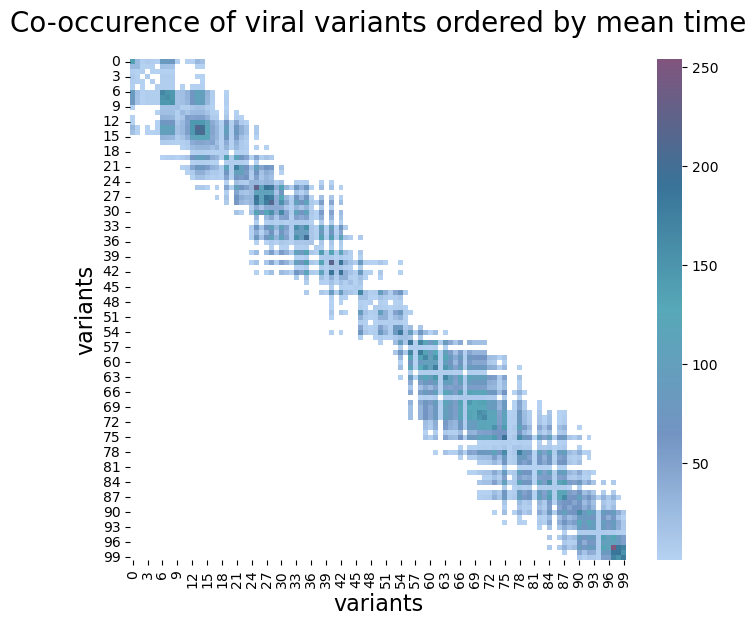

In [8]:
co_occurence_reorderd = calculate_cooccurence(data['counts'])
plot_heatmap(co_occurence_reorderd, "Co-occurence of viral variants ordered by mean time", "variants", "variants")

In [9]:
partition_size = 12
overlap_size = 4

estimator_stepwise = StepwiseBFGSCompositionEstimator(data['counts'], partition_size, overlap_size)
estimator_stepwise.fit()
result_stepwise = estimator_stepwise.get_results()

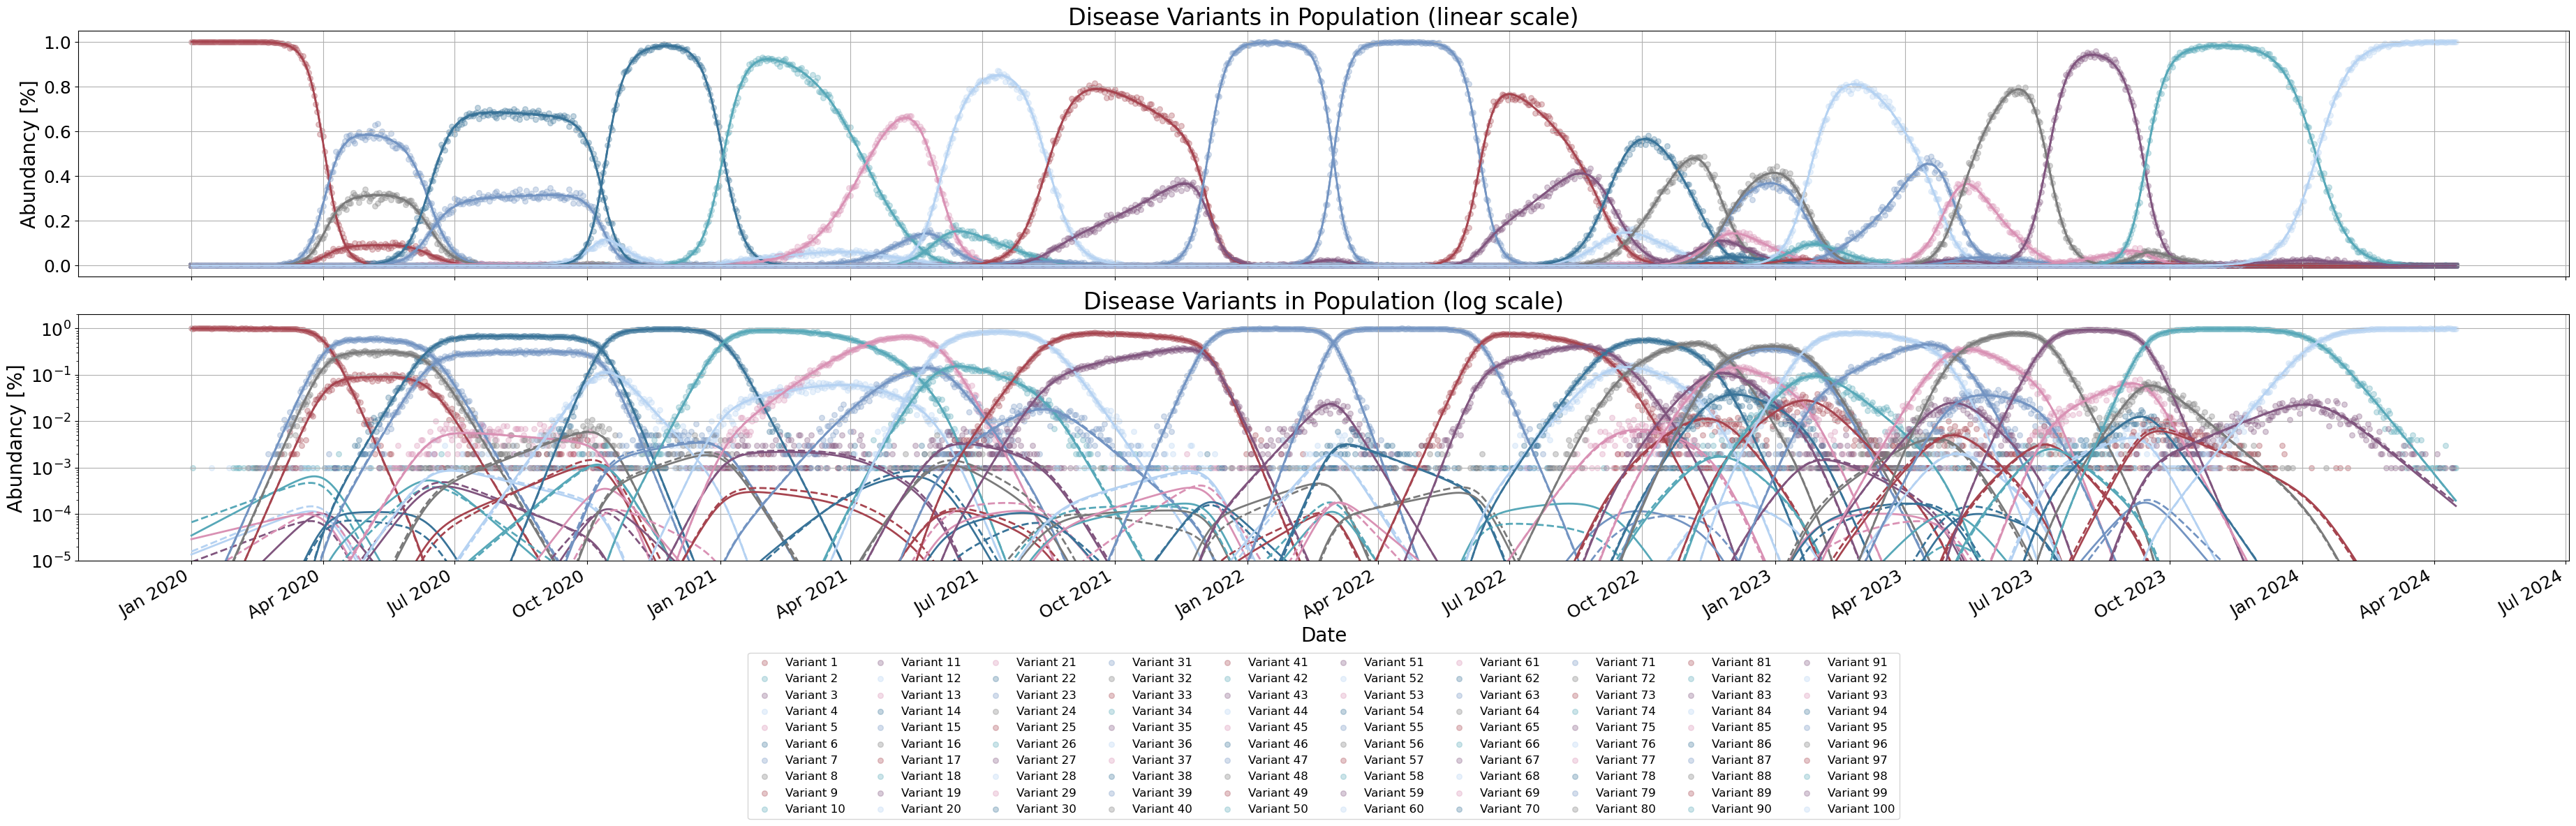

In [14]:
plot_viral_composition_dual(data['counts'], data['freq'], result_stepwise['composition_estimate'], y_range = (1e-5, 2), start_date="2020-01-01", path_to_save="figures/stepwise_composition_estimate_100.png")

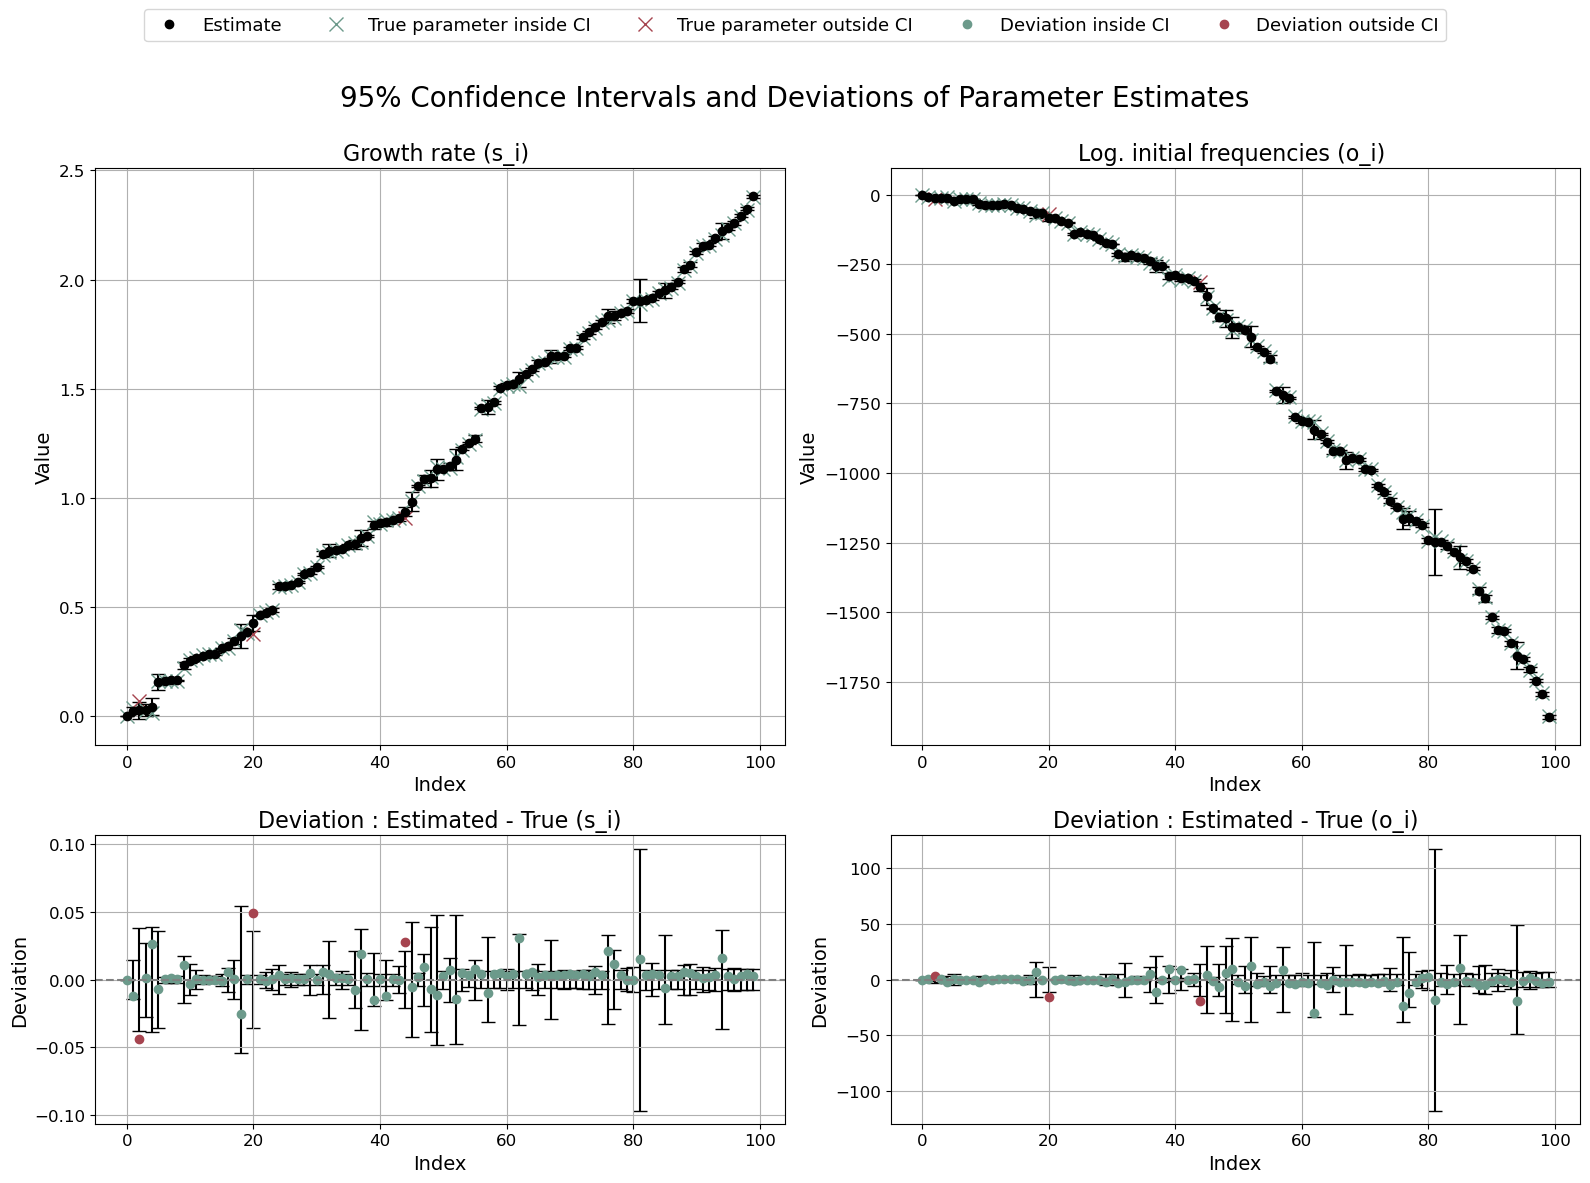

In [16]:
df_bfgs = evaluate_result(result_stepwise['growth_rate_estimate'], result_stepwise['log_init_freq_estimate'], result_stepwise['hess_inv'], data['growth_rates'], data['log_init_freq'])
plot_confidence_intervals_deviation(df_bfgs)

In [12]:
estimator_bfgs = BFGSCompositionEstimator(data['counts'])
estimator_stepwise.fit()
result_stepwise = estimator_stepwise.get_results()

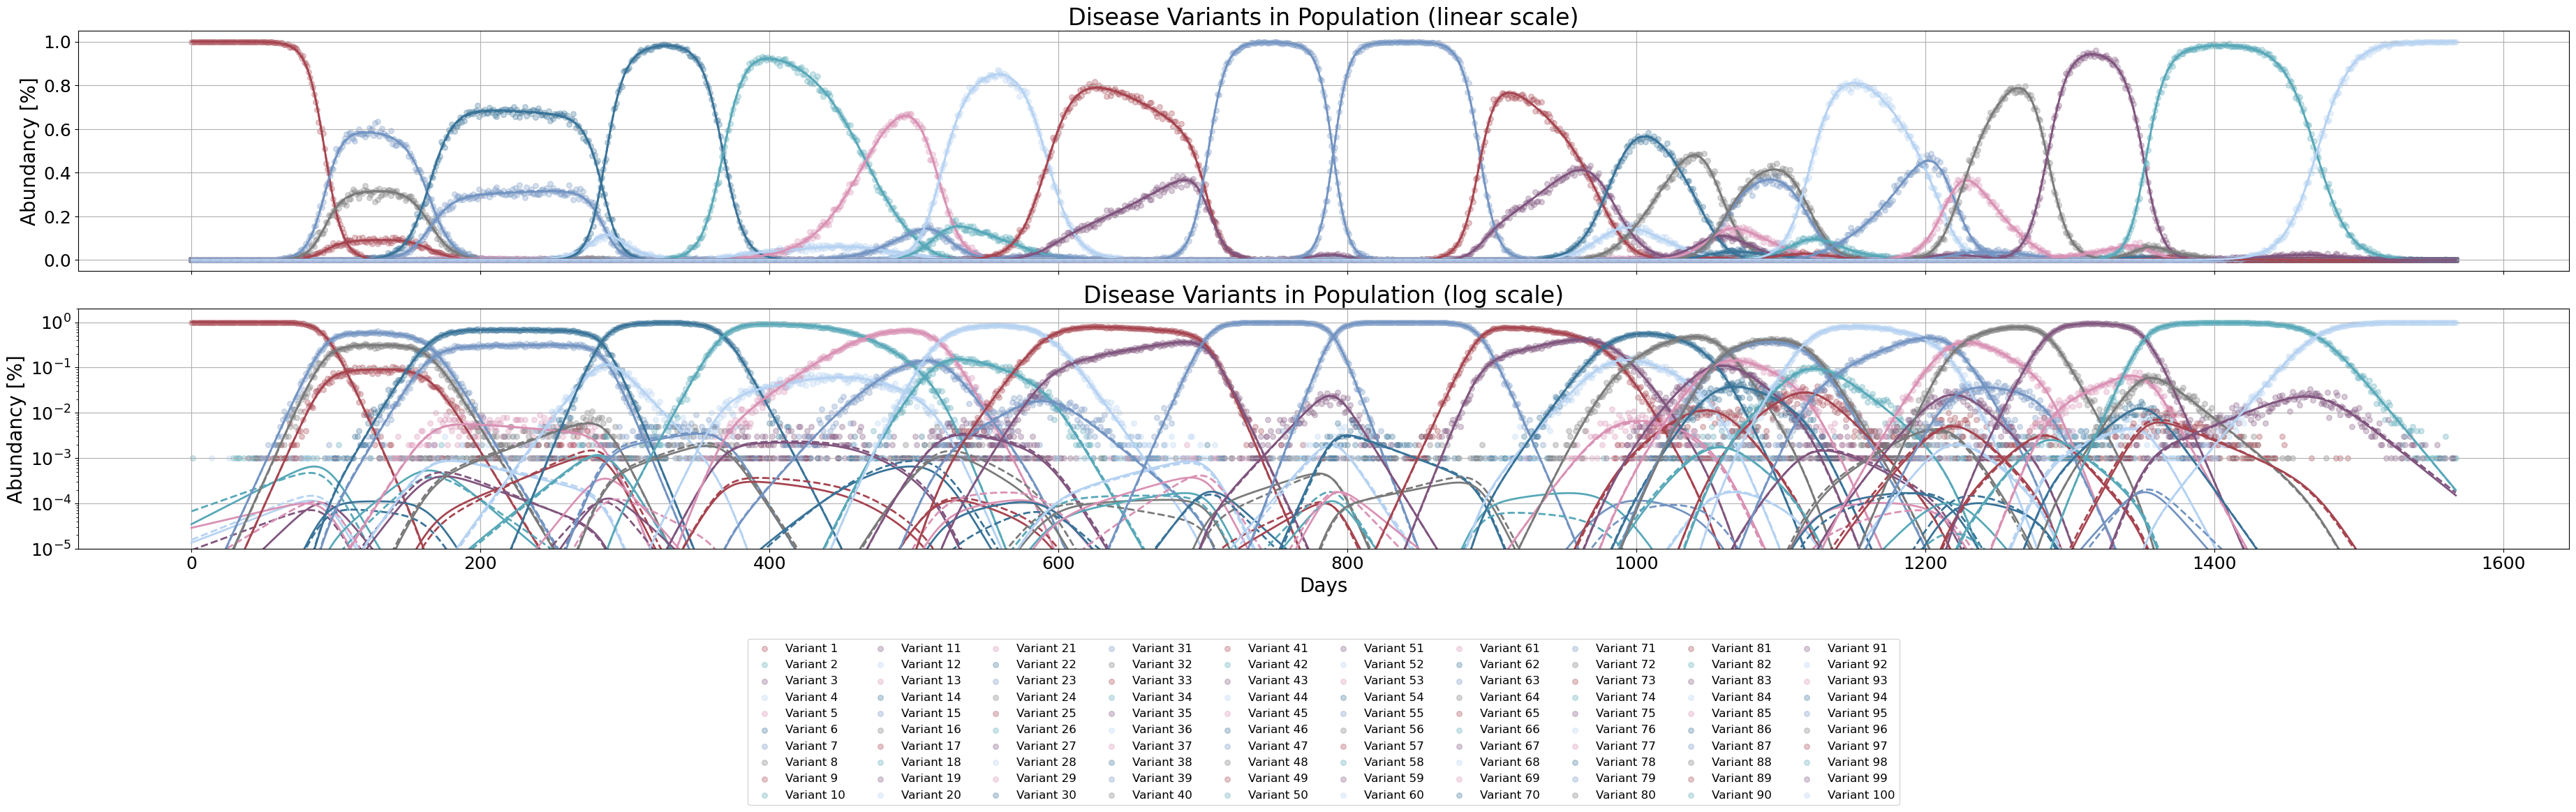

In [13]:
plot_viral_composition_dual(data['counts'], data['freq'], result_stepwise['composition_estimate'], y_range = (1e-5, 2), path_to_save="figures/bfgs_composition_estimate_100.png")

## Runtime comparison
Create plot with runtimes obtained above

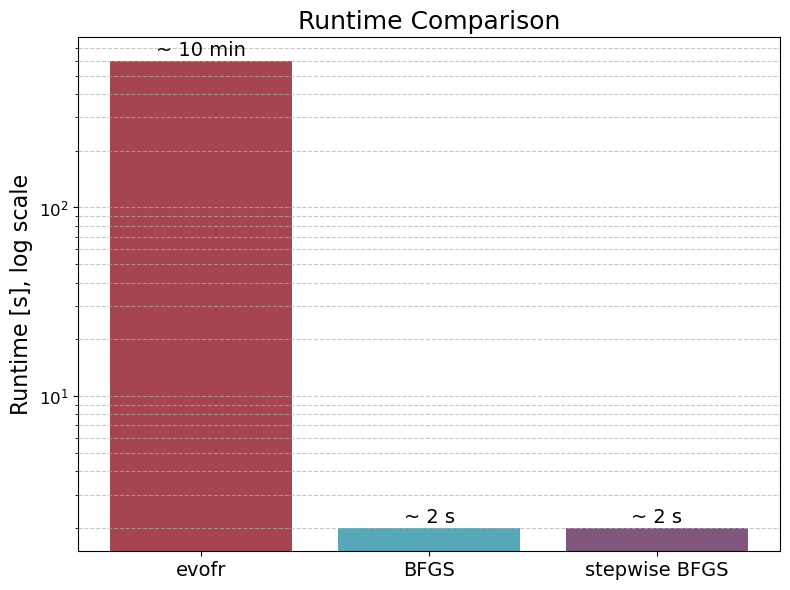

In [48]:
import matplotlib.pyplot as plt

# Data
methods = ['evofr', 'BFGS', 'stepwise BFGS']
values_seconds = [10 * 60, 2, 2]  

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(methods, values_seconds, color=['#a6444f', '#57a8b8', '#80557e'])

ax.set_yscale('log')

# Labels & title with larger font size
ax.set_ylabel('Runtime [s], log scale', fontsize=16)
ax.set_title('Runtime Comparison', fontsize=18)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=12)

# Add gridlines
ax.grid(axis='y', linestyle='--', alpha=0.7, which='both')

labels = ['~ 10 min', '~ 2 s', '~ 2 s']
for bar, label in zip(bars, labels):
    ax.annotate(label,
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 14),  # negative to move down
                textcoords="offset points",
                ha='center', va='top',  # align to top of reference point
                fontsize=14)


plt.tight_layout()
plt.show()
